## Simulation-Based Semivariogram
Notebook for developing the simulation-based semivariogram for spatial correlation

This uses the simulation-based within-event residuals. 

In [2]:
import itertools
from pathlib import Path

import einops
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr
import spatial_hazard as sh
from labelled_data_array import LabelledDataArray
import ml_tools as mlt

In [16]:
# Config
# sim_gm_params_dir = Path("/home/claudy/dev/work/data/sim_ranking/sim_gm_params/neil")
sim_gm_params_dir = Path("/Users/claudy/dev/work/data/sim_ranking/sim_derived/sim_gm_params/neil")
# db_ffp = Path("/home/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")

# Load general data
db = sr.db.DB(db_ffp)
site_df = db.get_site_df()

ims = sr.constants.IMs

In [17]:
# Load GM parameters, which include the within-event residuals
events = [cur_dir for cur_dir in sim_gm_params_dir.iterdir() if cur_dir.is_dir()]
gm_params = {}
for cur_event_dir in events:
    cur_event = cur_event_dir.stem
    cur_dir = sim_gm_params_dir / cur_event
    gm_params[cur_event] = sr.data.SimGMParams.load(cur_dir)

# Sites for which there is data
sites = np.unique(
    np.concatenate([cur_params.sites for cur_params in gm_params.values()])
)

In [18]:
# Compute the distance matrix
dist_matrix = sh.im_dist.calculate_distance_matrix(sites, site_df)

In [19]:
# Compute the relevant residual squared "errors"
residual_values = []
site_combs, site_combs_dist = [], []
site_combs_error = []
for cur_event, cur_gm_params in gm_params.items():
    cur_sites = cur_gm_params.sites
    cur_site_combs = np.asarray(list(itertools.combinations(cur_sites, 2)))

    cur_dist_matrix = dist_matrix.loc[cur_sites, cur_sites]

    cur_site_combs_dists = cur_dist_matrix.values[
        cur_dist_matrix.index.get_indexer_for(cur_site_combs[:, 0]),
        cur_dist_matrix.columns.get_indexer_for(cur_site_combs[:, 1]),
    ]

    # Only care about < 100km
    cur_m = cur_site_combs_dists < 100
    cur_site_combs = cur_site_combs[cur_m]
    cur_site_combs_dists = cur_site_combs_dists[cur_m]

    # Add event column
    cur_event_col = np.full(cur_site_combs.shape[0], cur_event)
    cur_event_site_combs = np.concatenate(
        [cur_event_col[:, None], cur_site_combs], axis=1
    )

    # cur_labels = mlt.array_utils.numpy_str_join("_", cur_event, cur_site_combs[:, 0], cur_site_combs[:, 1])

    cur_residuals_df = cur_gm_params.within_residuals.sort_values(["site", "rel"])
    cur_residuals = einops.rearrange(
        cur_residuals_df[ims].values,
        "(site rel) im -> site rel im",
        rel=25,
    )

    cur_residual_sites, t = np.unique(
        cur_residuals_df.site.values.astype(str), return_index=True
    )
    assert np.all(np.diff(t) > 0)
    cur_residual_labels = mlt.array_utils.numpy_str_join(
        "_", cur_event, cur_residual_sites
    )

    cur_residual_da = LabelledDataArray(
        cur_residuals,
        (cur_residual_sites, cur_residuals_df.rel.unique(), ims),
        ("site", "rel", "im"),
    )

    cur_idx_1 = cur_residual_da.get_indexer(cur_site_combs[:, 0], "site")
    cur_idx_2 = cur_residual_da.get_indexer(cur_site_combs[:, 1], "site")

    cur_error = (
        cur_residual_da.values[cur_idx_1] - cur_residual_da.values[cur_idx_2]
    ) ** 2
    site_combs_error.append(cur_error)

    residual_values.append(cur_residuals)
    site_combs.append(cur_event_site_combs)
    site_combs_dist.append(cur_site_combs_dists)

residual_values = np.concatenate(residual_values, axis=0)
site_combs = np.concatenate(site_combs, axis=0)
site_combs_dist = np.concatenate(site_combs_dist, axis=0)
site_combs_error = np.concatenate(site_combs_error, axis=0)

In [20]:
# Compute residual sigma
res_sigma = residual_values.std(axis=(0, 1))

In [21]:
# Compute empirical semivariogram
dist_bins_edges = np.linspace(0, 100, 36)
dist_bins_centers = 0.5 * (dist_bins_edges[:-1] + dist_bins_edges[1:])

gamma = []
n_station_pairs = []
n_observations = []
for bin_ix in range(dist_bins_edges.size - 1):
    cur_min, cur_max = dist_bins_edges[bin_ix], dist_bins_edges[bin_ix + 1]

    cur_m = (site_combs_dist >= cur_min) & (site_combs_dist < cur_max)
    cur_error = site_combs_error[cur_m]

    n_observations.append(site_combs[cur_m].shape[0])
    n_station_pairs.append(
        np.unique(
            mlt.array_utils.numpy_str_join(
                "_", site_combs[cur_m][:, 1], site_combs[cur_m][:, 2]
            )
        ).size
    )

    cur_error = einops.rearrange(cur_error, "site rel im -> (site rel) im")

    cur_gamma = 0.5 * cur_error.mean(axis=0)
    gamma.append(cur_gamma)
    
gamma = pd.DataFrame(data=np.asarray(gamma), columns=ims, index=dist_bins_centers)
n_station_pairs = np.asarray(n_station_pairs)
n_observations = np.asarray(n_observations)

# Compute covariance and correlations
cov = res_sigma - gamma.values
corr = cov / res_sigma

corr = pd.DataFrame(data=corr, columns=ims, index=dist_bins_centers)

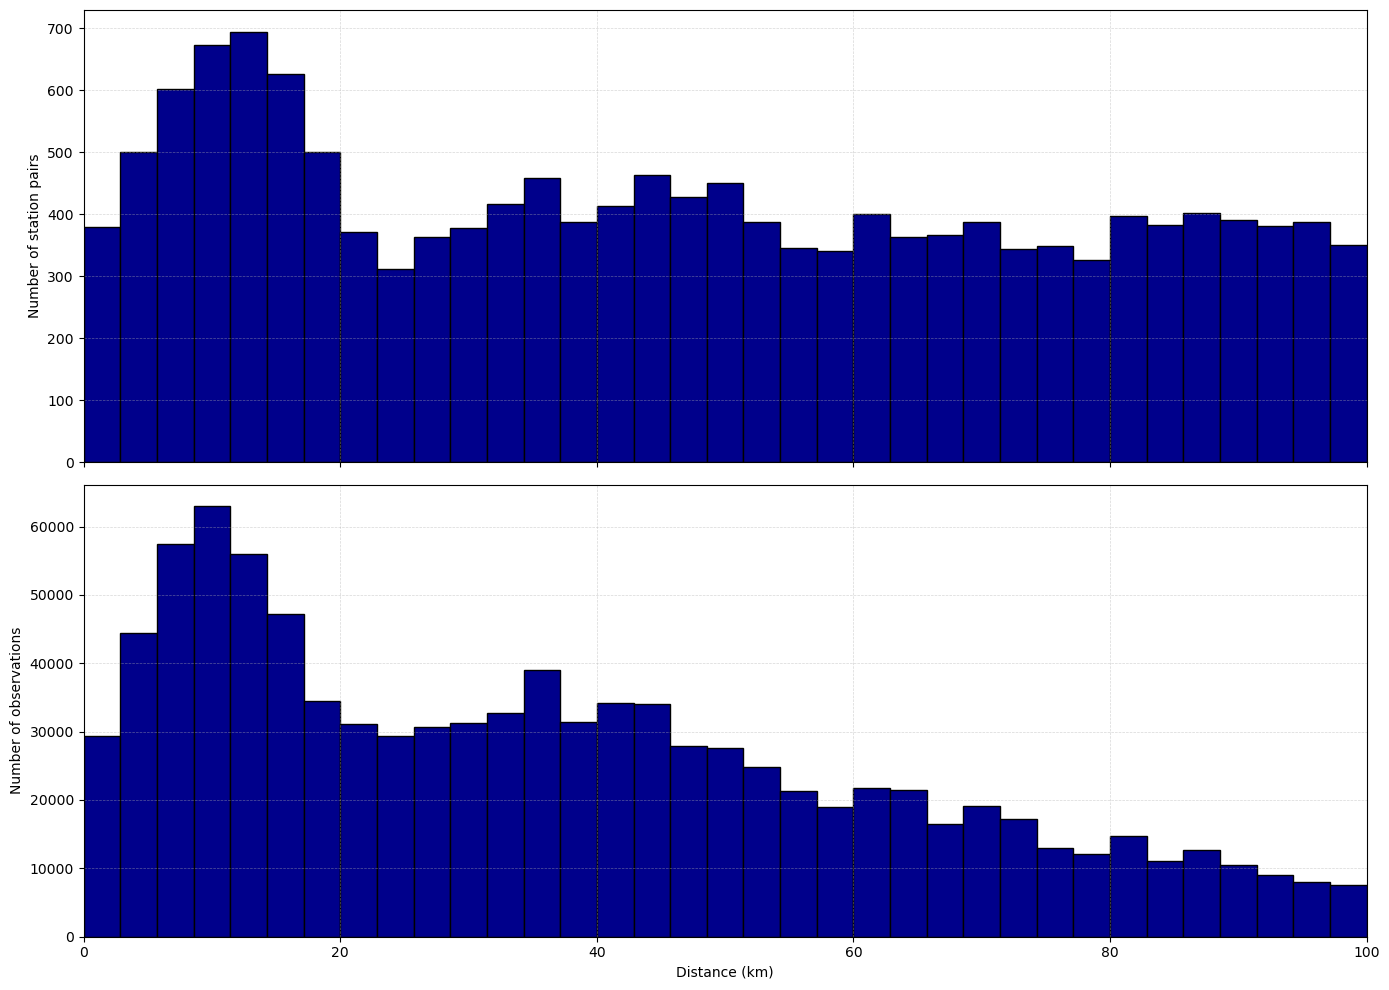

In [24]:
# Number of station pairs and number of observations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.bar(dist_bins_centers, n_station_pairs, width=100 / len(dist_bins_centers) , color="darkblue", edgecolor="black")
ax1.set_ylabel("Number of station pairs")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax2.bar(dist_bins_centers, n_observations, width=100 / len(dist_bins_centers), color="darkblue", edgecolor="black")
ax2.set_ylabel("Number of observations")
ax2.set_xlabel("Distance (km)")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlim(0, 100)

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)

In [26]:
# Plotting
plt_im = "pSA_10.0"

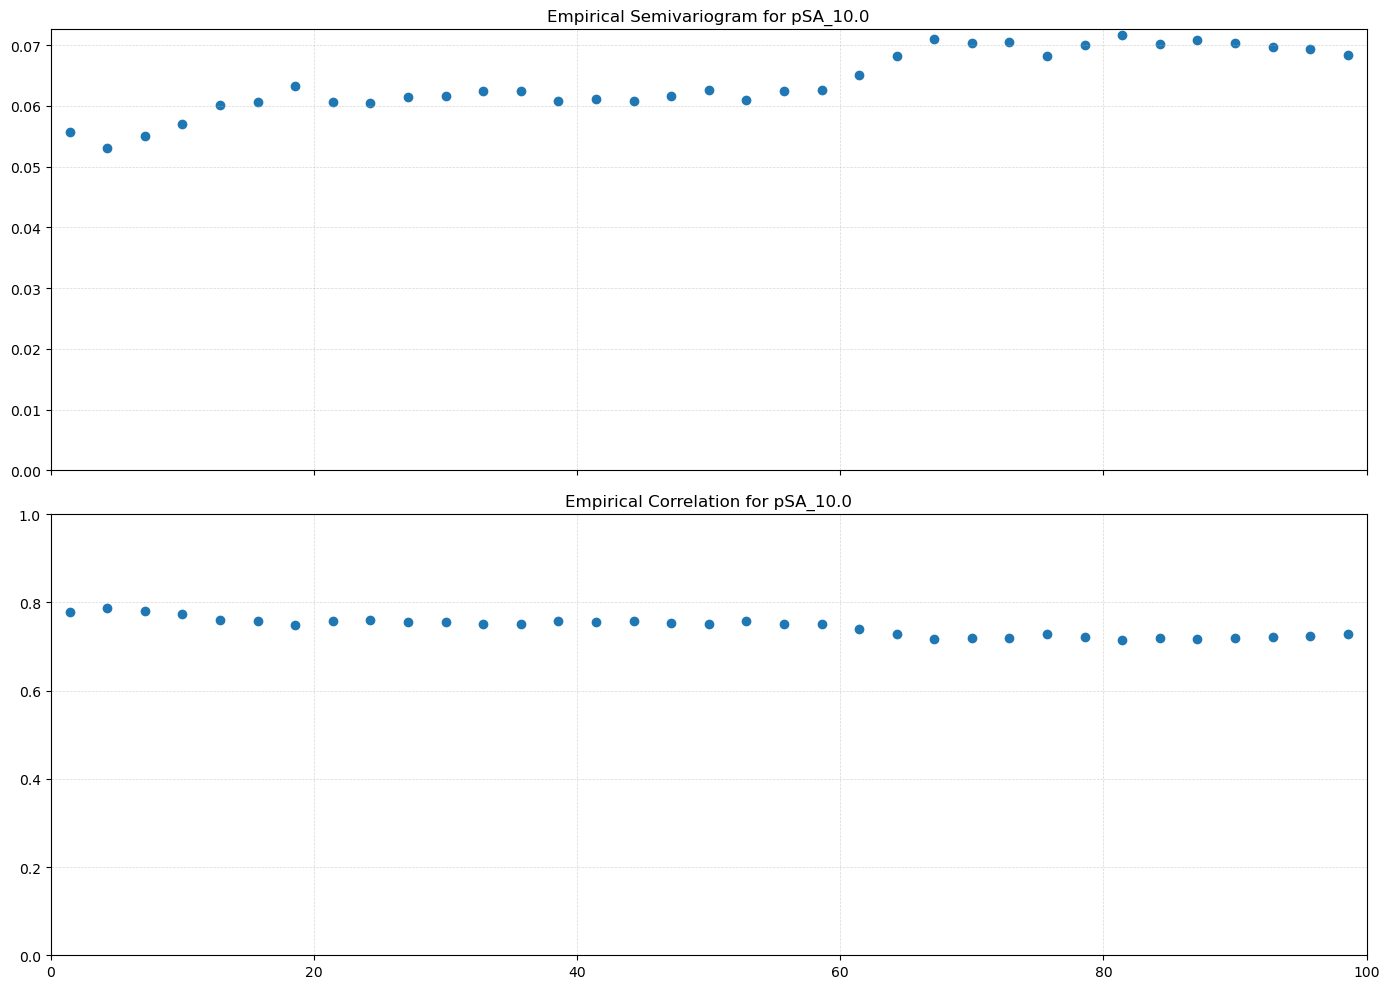

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.scatter(dist_bins_centers, gamma[plt_im])
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlim(0, 100)
ax1.set_ylim(0, None)
ax1.set_title(f"Empirical Semivariogram for {plt_im}")

ax2.scatter(dist_bins_centers, corr[plt_im])
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 1)
ax2.set_title(f"Empirical Correlation for {plt_im}")

fig.tight_layout()